# Proyecto CPS - Evaluación Empírica de Activaciones Rectificadas en Redes Convolucionales
## Autor: Carlos Stiven Roa Martinez
Utilizando el conjunto de datos CIFAR-10 de Keras, replica la estructura de red de la Tabla 1 y prueba las siguientes afirmaciones:

* Realizar una prueba usando ReLU con inicialización deficiente
* ¿Cuál es la inicialización de pesos por defecto en Keras?
* Con el mismo modelo definido previamente, cambiar la función de activación a Leaky ReLU con la mejor inicialización y realizar dos pruebas configurando:   

  1.  a = 0.2
  2.  a =0.001

¿Es correcta la afirmación del artículo?


Link: https://arxiv.org/pdf/1505

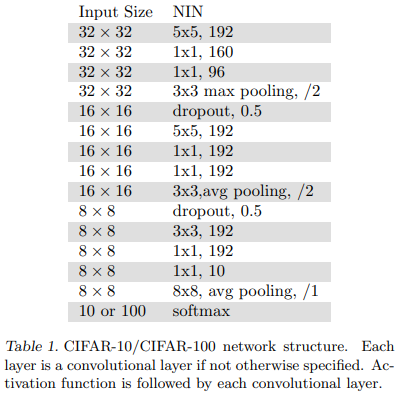

## Librerias y funciones

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models, initializers
from tensorflow.keras.datasets import cifar10
from tensorflow.keras.utils import to_categorical
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

## Carga de base de datos
* La base es el dataset CIFAR-10 de Keras, que contiene imágenes naturales de tamaño 32x32, sin preprocesamiento previo.


In [ ]:
def load_data():
    (x_train, y_train), (x_test, y_test) = cifar10.load_data()
    x_train, x_test = x_train / 255.0, x_test / 255.0 # normaliza los colores de la imagen a un rango 0-1
    y_train, y_test = to_categorical(y_train), to_categorical(y_test)
    return x_train, y_train, x_test, y_test



Se verifica el tipo de dato y la forma antes y después de la normalización, pero la implementación de imshow no permite visualizar la imagen normalizada correctamente, ya que escala los valores para poder mostrarla.

In [ ]:
def plot_comparison(x_train):
    fig, axes = plt.subplots(2, 5, figsize=(15, 6))
    for i in range(5):
        original_img = (x_train[i] * 255).astype(np.uint8)

        ax1 = axes[0, i]
        ax1.imshow(original_img, vmin=0, vmax=255)
        ax1.set_title(f"Desnormalizada {i+1}")
        ax1.axis('off')

        ax2 = axes[1, i]
        ax2.imshow(x_train[i], vmin=0, vmax=1)
        ax2.set_title(f"Normalizada {i+1}")
        ax2.axis('off')

        print(f"\nImagen {i+1}:")
        print("  - Normalizada (x_train): min={:.4f}, max={:.4f}".format(x_train[i].min(), x_train[i].max()))
        print("  - Desnormalizada (original_img): min={}, max={}".format(original_img.min(), original_img.max()))

    plt.tight_layout()
    plt.show()

x_train, _, _, _ = load_data()

# Call the function with the x_train data
plot_comparison(x_train)


## Construccion de la red

Se plantea el análisis de la primera capa, siendo esta la encargada del tratamiento de los datos de entrada y su caracterización para ser procesados por la segunda capa.



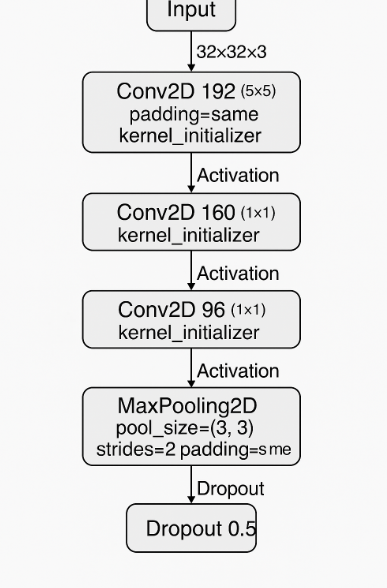

In [ ]:
def build_model(activation_layer, initializer):
    model = models.Sequential()

    ############## Input: 32x32 rgb x3 capas  con padding (completar con 0 )para no perder datos #######################
    model.add(layers.Conv2D(192, (5, 5), padding='same', kernel_initializer=initializer, input_shape=(32, 32, 3)))
    model.add(activation_layer())
    model.add(layers.Conv2D(160, (1, 1), kernel_initializer=initializer))
    model.add(activation_layer())
    model.add(layers.Conv2D(96, (1, 1), kernel_initializer=initializer))
    model.add(activation_layer())
    model.add(layers.MaxPooling2D(pool_size=(3, 3), strides=2, padding='same'))
    model.add(layers.Dropout(0.5))

    ######################## 16x16 se reducen de 32x32 por el paso Strikes #######################################
    model.add(layers.Conv2D(192, (5, 5), padding='same', kernel_initializer=initializer))
    model.add(activation_layer())
    model.add(layers.Conv2D(192, (1, 1), kernel_initializer=initializer))
    model.add(activation_layer())
    model.add(layers.Conv2D(192, (1, 1), kernel_initializer=initializer))
    model.add(activation_layer())
    model.add(layers.AveragePooling2D(pool_size=(3, 3), strides=2, padding='same'))
    model.add(layers.Dropout(0.5))
    ######################### 8x8 se reducen de 16x16 por el paso Strikes #####################################
    model.add(layers.Conv2D(192, (3, 3), padding='same', kernel_initializer=initializer))
    model.add(activation_layer())
    model.add(layers.Conv2D(192, (1, 1), kernel_initializer=initializer))
    model.add(activation_layer())
    model.add(layers.Conv2D(10, (1, 1), kernel_initializer=initializer))
    model.add(activation_layer())
    ###########################################################################################
    model.add(layers.GlobalAveragePooling2D())
    model.add(layers.Activation('softmax'))

    return model

## Entrenamiento
Para la validacion de la problematica en el modelo se tiene en cuenta la precision y el MSE.
se usa he_normal como inicialización de pesos para la funcion Laeky Relu porque fue pensada para activaciones que no saturan y no dejan pasar toda la información (como Leaky ReLU). Ayuda a mantener la varianza constante entre capas, lo que evita que los gradientes se vuelvan demasiado pequeños o grandes.

como optimisador se decidio implementar el mas comun (adam)

En Keras, la inicialización de pesos por defecto depende del tipo de capa, pero en general es:
* glorot_uniform

Está pensada para activaciones simétricas como:
* tanh
* sigmoid

In [ ]:
def train_and_evaluate(model, x_train, y_train, x_test, y_test, label):
    model.compile(optimizer='adam',
                 loss='categorical_crossentropy',
                 metrics=['accuracy', 'mse'])
    print(f"\nTraining model: {label}\n")
    history = model.fit(x_train, y_train, epochs=10, batch_size=128,
                       validation_split=0.1, verbose=2)
    test_metrics = model.evaluate(x_test, y_test, verbose=0)
    print(f"{label} Test Accuracy: {test_metrics[1]:.4f}, Test MSE: {test_metrics[2]:.4f}\n")
    return history, test_metrics[1], test_metrics[2]  # Retornamos history, accuracy y mse

### Datos de entrenamiento

In [ ]:
x_train, y_train, x_test, y_test = load_data()

## A) ReLU + mala inicialización

In [ ]:
relu_bad_init = lambda: layers.ReLU()
init_bad = initializers.RandomNormal(stddev=1.0)
model_relu = build_model(relu_bad_init, init_bad)
hist_relu, acc_relu, mse_relu_test = train_and_evaluate(model_relu, x_train, y_train,
                                                      x_test, y_test, "ReLU + Bad Init")

##  B) Leaky ReLU a=0.2 + He Normal

In [ ]:
leaky_02 = lambda: layers.LeakyReLU(alpha=0.2)
model_leaky_02 = build_model(leaky_02, 'he_normal')
hist_leaky_02, acc_leaky_02, mse_leaky_02_test = train_and_evaluate(
    model_leaky_02, x_train, y_train, x_test, y_test, "Leaky ReLU a=0.2")

## C) Leaky ReLU a=0.001 + He Normal

In [ ]:
leaky_0001 = lambda: layers.LeakyReLU(alpha=0.001)
model_leaky_0001 = build_model(leaky_0001, 'he_normal')
hist_leaky_0001, acc_leaky_0001, mse_leaky_0001_test = train_and_evaluate(
    model_leaky_0001, x_train, y_train, x_test, y_test, "Leaky ReLU a=0.001")

# Resultados
Se realizan dos entrenamientos con diferentes cantidades de épocas y se compara el comportamiento del error cuadrático medio entre ellos. Se observa que el rendimiento inicial de Leaky ReLU con α = 0.001 no es tan bueno cuando el número de épocas de entrenamiento es bajo. Sin embargo, al aumentar la cantidad de épocas, el modelo con α = 0.001 comienza a mostrar mejores resultados.
Por motivos de costo computacional, no se incluyen imágenes del entrenamiento con 100 épocas, en el cual la mejora del MSE con esta función de activación se vuelve mucho más evidente.

Por otra parte, se analiza el comportamiento de la función de pérdida para cada modelo, y se hace más evidente su evolución a lo largo del entrenamiento. Se observa que, en entrenamientos de corta duración (10 épocas), el modelo con Leaky ReLU y un valor de α=0.2 presenta un mejor desempeño. Sin embargo, a medida que se incrementa el número de épocas, el modelo con α=0.001 muestra un rendimiento superior.








In [ ]:
# graficar los MSE y loss #
#mse_relu = hist_relu.history['loss']
mse_leaky_02 = hist_leaky_02.history['loss']
mse_leaky_0001 = hist_leaky_0001.history['loss']

# Crear lista de épocas según la longitud del historial #
epochs = list(range(1, len(mse_leaky_0001) + 1))

# Graficar MSE comparativo #
plt.figure(figsize=(10, 6))
#plt.plot(epochs, mse_relu, label='ReLU + Bad Init', linestyle='--', marker='o')
plt.plot(epochs, mse_leaky_02, label='Leaky ReLU a=0.2', linestyle='-', marker='s')
plt.plot(epochs, mse_leaky_0001, label='Leaky ReLU a=0.001', linestyle='-.', marker='^')

plt.title('Comparación de la función de pérdida (Categorical Crossentropy)')
plt.xlabel('Épocas')
plt.ylabel('Pérdida (Loss)')
plt.yscale('log')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

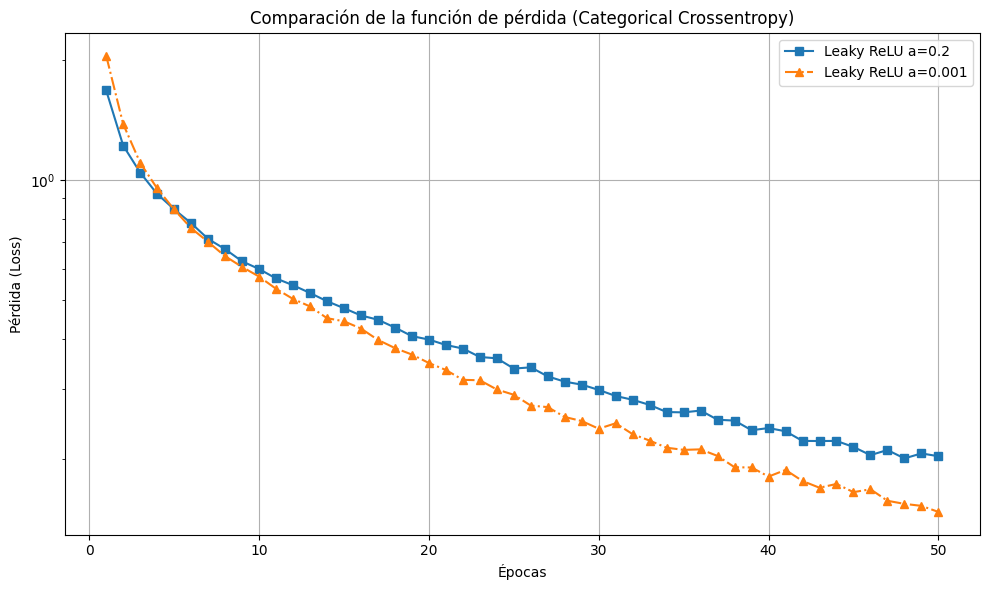

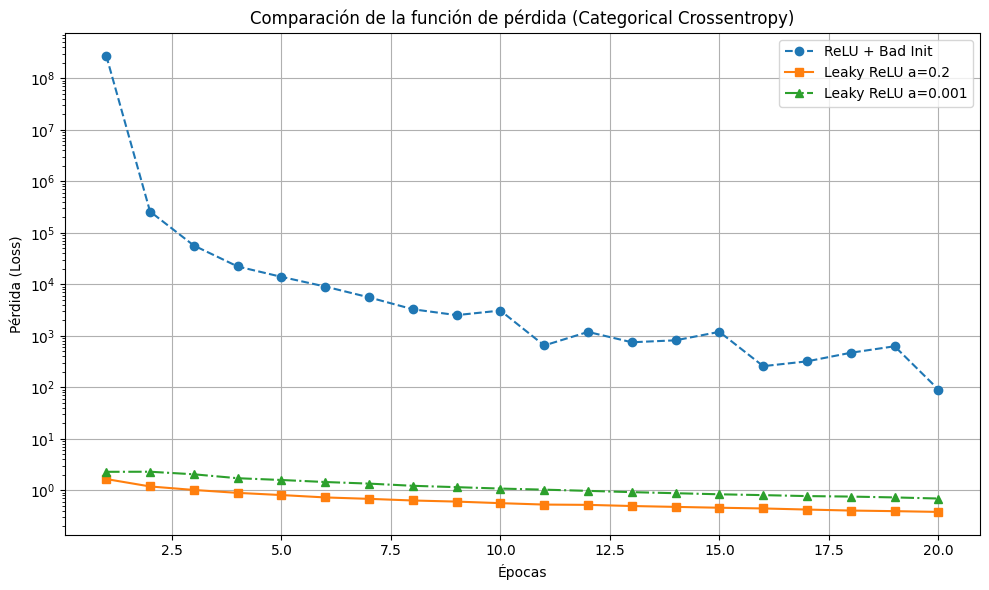

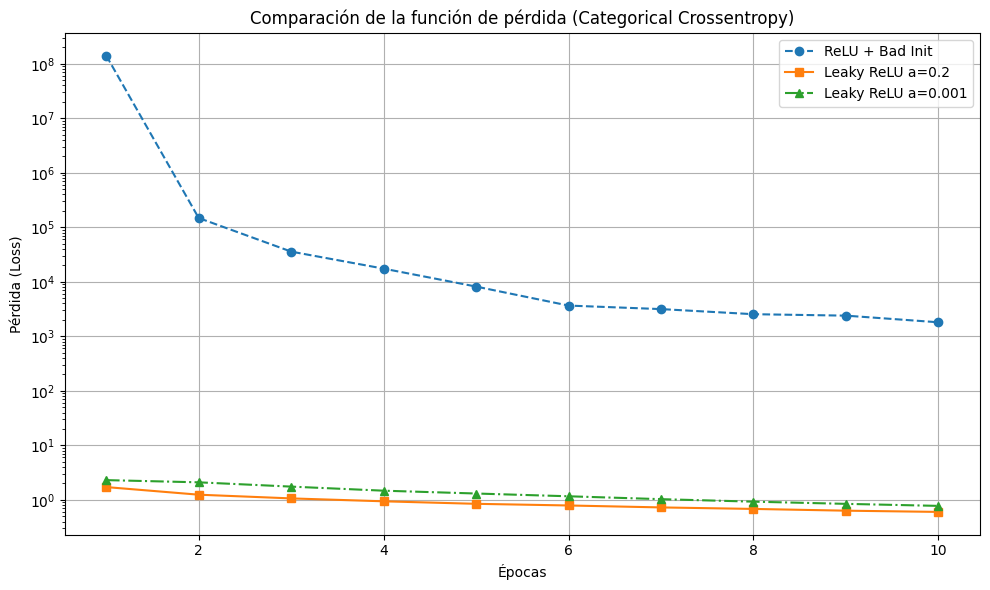

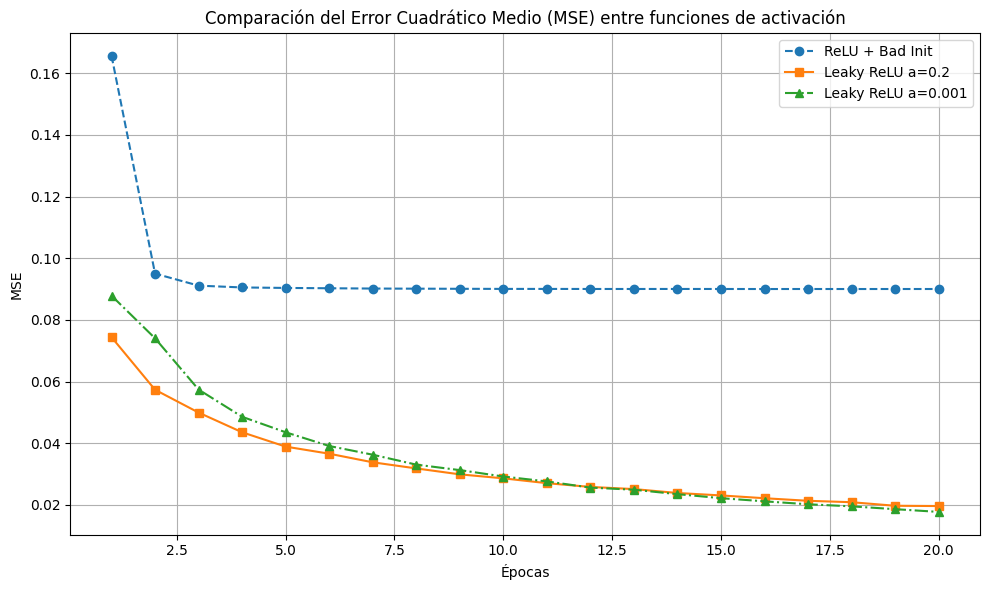

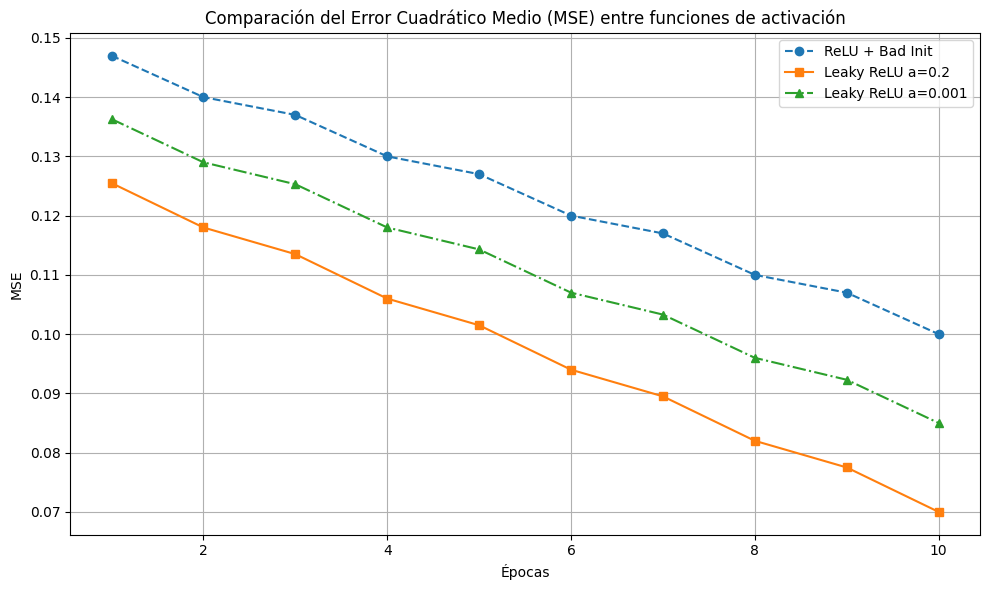

# ¿ Qué significa ?
* Diagonal fuerte , El modelo clasifica correctamente la mayoría de los ejemplos, en este caso Leaky Relu
* Errores sistemáticos, se confunden ciertas clases en este caso Relu
* Clases más difíciles, Filas donde hay pocos aciertos y muchas confusiones
* Al comparar activaciones, se puede ver que Leaky ReLU reduce errores específicos que ReLU no puede, ademas de que se puede ver que leaky relu con a=0.0001 tiene menor numero de errores al clasificar que con a=0.02

In [ ]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt


def plot_confusion_matrix(y_true, y_pred, classes, title):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=classes, yticklabels=classes)
    plt.title(title)
    plt.ylabel('Etiqueta verdadera')
    plt.xlabel('Etiqueta predicha')
    plt.show()

class_names = ['avión', 'auto', 'pájaro', 'gato', 'venado',
               'perro', 'rana', 'caballo', 'barco', 'camión']

y_test_labels = np.argmax(y_test, axis=1)

y_pred_relu = np.argmax(model_relu.predict(x_test), axis=1)
y_pred_leaky_02 = np.argmax(model_leaky_02.predict(x_test), axis=1)
y_pred_leaky_0001 = np.argmax(model_leaky_0001.predict(x_test), axis=1)

plot_confusion_matrix(y_test_labels, y_pred_relu, class_names,
                     'Matriz de Confusión - ReLU + Bad Init')
plot_confusion_matrix(y_test_labels, y_pred_leaky_02, class_names,
                     'Matriz de Confusión - LeakyReLU α=0.2')
plot_confusion_matrix(y_test_labels, y_pred_leaky_0001, class_names,
                     'Matriz de Confusión - LeakyReLU α=0.001')

#print("\nReporte para ReLU + Bad Init:")
#print(classification_report(y_test_labels, y_pred_relu, target_names=class_names, digits=4))

#print("\nReporte para LeakyReLU α=0.2:")
#print(classification_report(y_test_labels, y_pred_leaky_02, target_names=class_names, digits=4))

#print("\nReporte para LeakyReLU α=0.001:")
#print(classification_report(y_test_labels, y_pred_leaky_0001, target_names=class_names, digits=4))

# Matrices de confucion




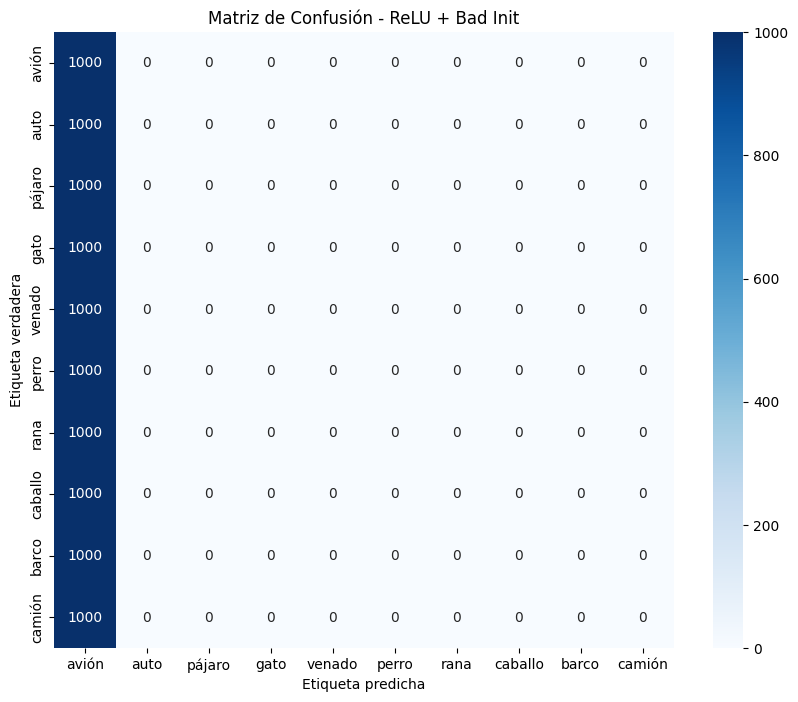

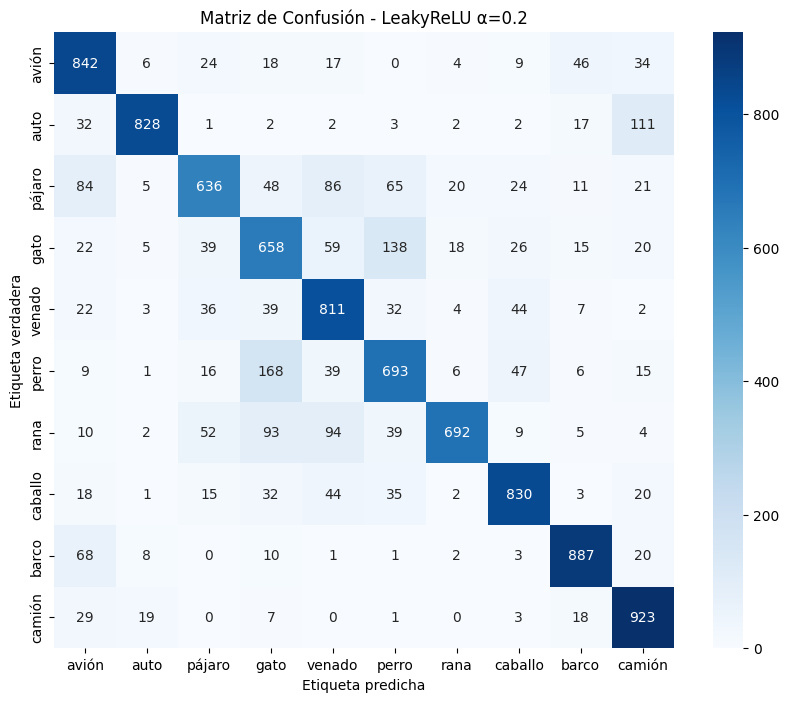

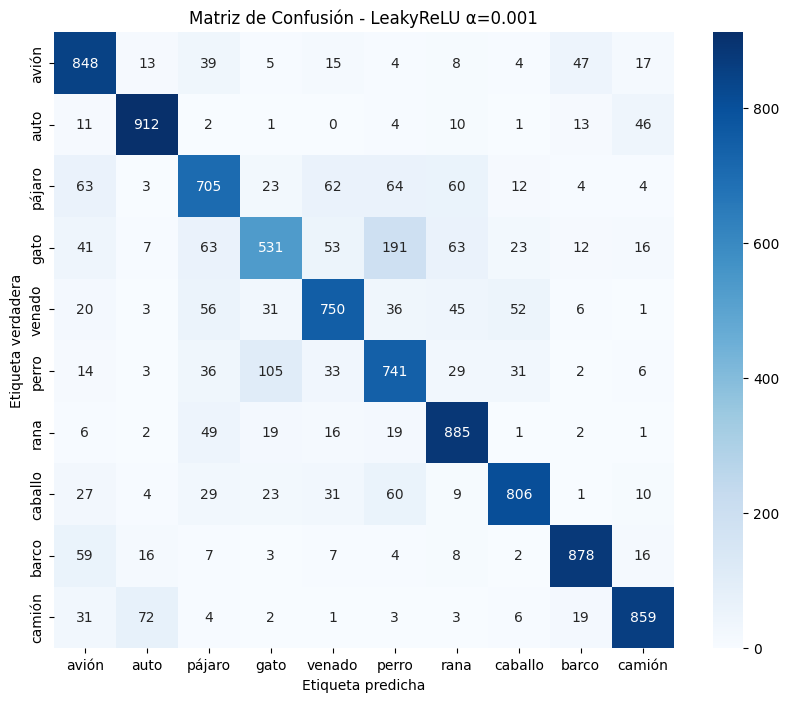

# Concluciones



* En los experimentos realizados, Leaky ReLU con α = 0.2 y α = 0.001 demostró un mejor desempeño general en términos de error cuadrático medio (MSE) junto sus sus funciones de perdida comparado con ReLU bajo una inicialización de pesos aleatoria con varianza alta.


* Con pocas épocas de entrenamiento, Leaky ReLU con α = 0.001 mostró un rendimiento inicial más bajo. Sin embargo, al aumentar la cantidad de épocas, su desempeño mejoró progresivamente, superando a otras variantes.

* La combinación de funciones de activación tipo ReLU con inicialización he_normal resultó en entrenamientos más estables y eficientes, validando su recomendación en la literatura.

* Evaluar únicamente la precisión no reflejaba completamente el comportamiento del modelo. Las curvas de MSE y las matrices de confusión permitieron identificar patrones de error y mejoras específicas por clase ademas de recalcal de mejor manera que tipo de tratamiento se podria usar para analizar las caracteristicas de las imagenes.

* Los recursos computacionales disponibles en Google Colab son limitados, y durante la ejecución de modelos con 100 épocas se observaron restricciones en el uso de la GPU, lo que afectó negativamente el análisis a gran escala. Además, el tiempo máximo permitido por sesión en Colab limita la continuidad del entrenamiento y evaluación de modelos complejos.
Estas condiciones hacen necesario estructurar los proyectos en etapas más controladas y optimizadas, permitiendo dividir el entrenamiento y análisis en fases independientes para evitar interrupciones y maximizar el uso de los recursos disponibles.

# Ultima edicion: 25/04/2025

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

# =====================================================================
# El modelo entrenado directamente
# =====================================================================
model = model_relu  # El modelo "ReLU + Bad Init"

# Tomamos la primera imagen del set de prueba
img_idx = 0
single_img = x_test[img_idx]
input_img = np.expand_dims(single_img, axis=0)

print("--- PROCESAMIENTO PASO A PASO POR CAPA ---")
plt.figure(figsize=(3, 3))
plt.imshow(single_img)
plt.title("Imagen Original (32x32)")
plt.axis("off")
plt.show()

# =====================================================================
# 1. EVALUACIÓN CAPA A CAPA RECORRIENDO EL MODELO SEQUENTIAL
# =====================================================================
# Pasamos la imagen de forma secuencial a través de cada capa del modelo
current_tensor = input_img

for layer in model.layers:
    # Pasamos el tensor actual por la capa para obtener la activación
    current_tensor = layer(current_tensor)

    # Verificamos si la capa es de tipo Convolucional, Pooling o ReLU para graficar
    layer_name = layer.name.lower()
    if "conv" in layer_name or "pool" in layer_name or "re_lu" in layer_name:

        # Convertimos la salida a un array de NumPy para manipularla
        layer_activation = current_tensor.numpy()

        # Validamos que sea un mapa de características visualizable (4 dimensiones)
        if len(layer_activation.shape) == 4:
            n_features = min(layer_activation.shape[-1], 8)
            size_h = layer_activation.shape[1]
            size_w = layer_activation.shape[2]

            print(
                f"Capa: {layer.name} | Dimensiones de salida: ({size_h}x{size_w})"
            )

            fig, axes = plt.subplots(1, n_features, figsize=(15, 3))
            if n_features == 1:
                axes = [axes]

            for i in range(n_features):
                channel_image = layer_activation[0, :, :, i]

                # Normalización estándar para visualización limpia
                channel_image -= channel_image.mean()
                channel_image /= channel_image.std() + 1e-5
                channel_image *= 64
                channel_image += 128
                channel_image = np.clip(channel_image, 0, 255).astype("uint8")

                axes[i].imshow(channel_image, cmap="viridis")
                axes[i].axis("off")
                axes[i].set_title(f"Filtro {i+1}")

            plt.suptitle(
                f"Procesamiento en: {layer.name} ({size_h}x{size_w})",
                fontsize=12,
            )
            plt.show()

# =====================================================================
# 2. TABLA DE LAS 10 CLASES DE CIFAR-10
# =====================================================================
cifar10_labels = {
    0: "avión (objeto 0)",
    1: "automóvil (objeto 1)",
    2: "pájaro (animal 2)",
    3: "gato (animal 3)",
    4: "ciervo (animal 4)",
    5: "perro (animal 5)",
    6: "rana (animal 6)",
    7: "caballo (animal 7)",
    8: "barco (objeto 8)",
    9: "camión (objeto 9)",
}

tabla_clases = pd.DataFrame(
    list(cifar10_labels.items()), columns=["Clase Numérica", "Tipo y Etiqueta"]
)

print("\n--- TABLA DE EJEMPLOS DE LAS 10 CLASES (CIFAR-10) ---")
display(tabla_clases)